# Google Colab Setup

## Set up a personal access token for colab

### Part 1: github token
1. On your github go to: https://github.com/settings/personal-access-tokens/new
2. Set `Token name *` to: `the-space-cats-colab`
3. Set `Experiation` to `No expiration`
4. Under `Repository access`:
  *   Select option `Only select repositories`
  *   Search and select repo `the-space-cats-project`
5. Under `Permissions`:
    *  Click `Add permissions`
    *  Select option `Contents`
    *  Change `Access: Read-only` to `Access: Read and write`
6. Double check everytjing matches the picture below
7. Save the generated token somewhere safe


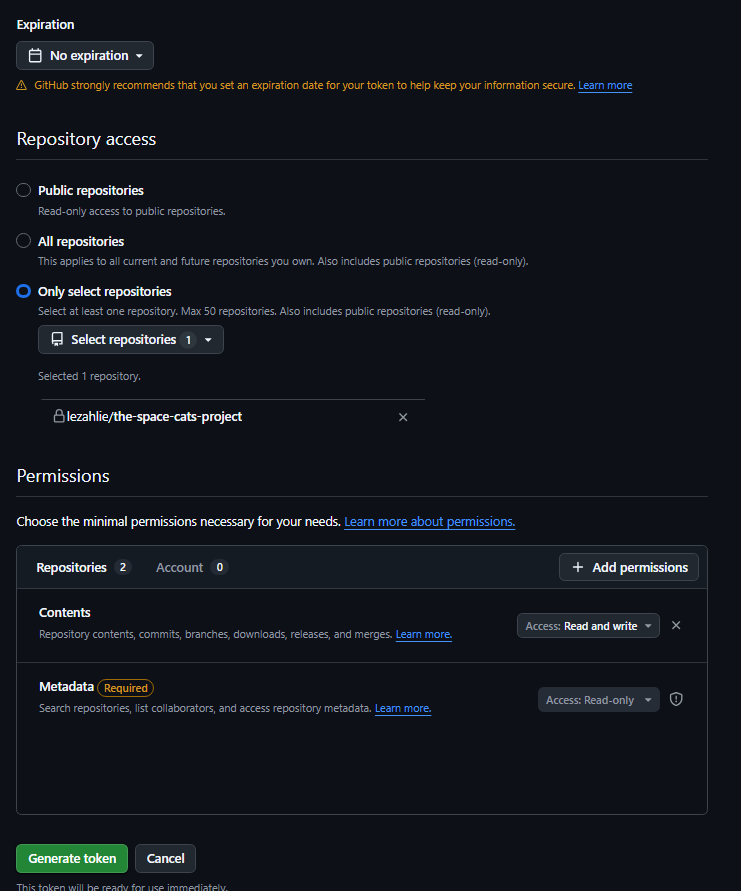

### Part 2: google colab secret

1. In Google Colab select the `Secrets` (key icon) tab
2. Add new secret with name `SPACECATS_GITHUB_TOKEN`
3. Paste the generated token saved from Part 2 - Step 7 in the value field
4. Make sure Notebook access is enabled
5. Confirm with the picture below

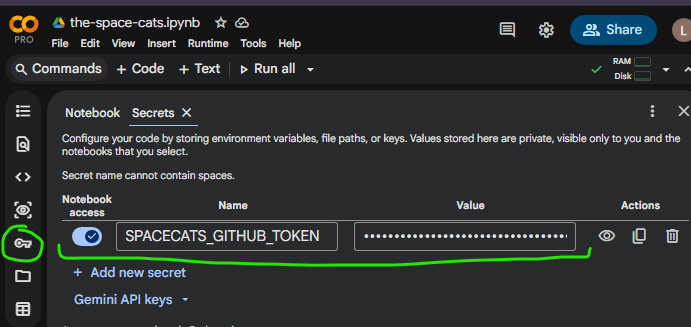

## Clone the repo with the new token

In [1]:
from google.colab import userdata, drive
import urllib.parse
import subprocess
import os
import sys

drive.mount('/content/drive')
token = urllib.parse.quote(userdata.get("SPACECATS_GITHUB_TOKEN"), safe="")
owner = "lezahlie"
repo_dir = "/content/drive/MyDrive/the-space-cats-project"

!git clone https://{token}@github.com/lezahlie/the-space-cats-project.git "$repo_dir"

# enter the repo
%cd $repo_dir

# verify this is now a git repo
!git status

# pull latest
!git pull

Mounted at /content/drive
fatal: destination path '/content/drive/MyDrive/the-space-cats-project' already exists and is not an empty directory.
/content/drive/MyDrive/the-space-cats-project
Refresh index: 100% (31/31), done.
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Already up to date.


## Install dependancies

In [2]:
%pip install --extra-index-url https://download.pytorch.org/whl/cu118 \
  torch==2.4.1 \
  torchaudio==2.4.1 \
  torchvision==0.19.1 \
  numpy \
  scipy \
  scikit-learn \
  scikit-image \
  torchmetrics \
  optuna \
  h5py \
  jsonschema \
  pandas \
  pyyaml \
  matplotlib \
  seaborn

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.5/857.5 MB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 113.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 137.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.9/142.9 MB 17.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.5/209.5 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### Download datasets and test the code

1. Download `galaxiesml_tiny.tar.gz` from: https://gtvault-my.sharepoint.com/:u:/r/personal/lhorace3_gatech_edu/Documents/DLGroupProject_Datasets/galaxiesml_tiny.tar.gz?csf=1&web=1&e=MaHjh7
2. Upload the `galaxiesml_tiny.tar.gz` to your google drive `Mydrive`
3. Run the below cell to extract it to the `data` folder

In [18]:
!mkdir -p /content/drive/MyDrive/the-space-cats-project/data
!tar -xzf /content/drive/MyDrive/galaxiesml_tiny.tar.gz -C /content/drive/MyDrive/the-space-cats-project/data/

### Test the code templates work

In [28]:
old_pythonpath = os.environ.get("PYTHONPATH", "")
paths = old_pythonpath.split(":") if old_pythonpath else []

if repo_dir not in paths:
    os.environ["PYTHONPATH"] = f"{repo_dir}:{old_pythonpath}" if old_pythonpath else repo_dir

if repo_dir not in sys.path:
    sys.path.insert(0, repo_dir)

print("PYTHONPATH =", os.environ.get("PYTHONPATH", ""))
print("sys.path[0] =", sys.path[0])

PYTHONPATH = /content/drive/MyDrive/the-space-cats-project:/content/the-space-cats-project
sys.path[0] = /content/drive/MyDrive/the-space-cats-project


In [29]:
!python src/models/CNNEncoder.py

[2026-04-12 08:42:44,972] || [INFO] || init_shared_logger: CNNEncoder
[2026-04-12 08:42:45,243] || [INFO] || [device.py:setup_torch_device:108] || Pytorch version: 2.4.1+cu118
[2026-04-12 08:42:45,245] || [INFO] || [device.py:setup_torch_device:109] || CUDA Support: True
[2026-04-12 08:42:45,245] || [INFO] || [device.py:setup_torch_device:110] || MPS Support: False
[2026-04-12 08:42:45,247] || [INFO] || [device.py:setup_torch_threads:12] || Setting up PyTorch threads
[2026-04-12 08:42:45,249] || [INFO] || [device.py:setup_torch_threads:25] || Max usable CPU threads: 1
[2026-04-12 08:42:45,250] || [INFO] || [device.py:setup_torch_threads:26] || Max usable inter-op threads: 1
[2026-04-12 08:42:45,251] || [INFO] || [device.py:setup_cuda:53] || CUDA is available, CUDA version: 11.8
[2026-04-12 08:42:45,252] || [INFO] || [device.py:setup_cuda:55] || Available GPUs: 1
[2026-04-12 08:42:45,253] || [INFO] || [device.py:setup_cuda:63] || Setting GPU list '0' and process memory fraction '0.5'
[2

In [ ]:
!python src/preprocess_data.py \
--input-folder data/galaxiesml_tiny \
--output-folder data/preprocessed \
--num-cores 2 \
--mask-ratio 0.50 \
--debug

[2026-04-12 08:44:29,042] || [INFO] || init_shared_logger: tune_model
[2026-04-12 08:44:29,047] || [INFO] || [logger.py:wrapper:147] || Starting clock for main at 2026-04-12 08:44:29.044802
[2026-04-12 08:44:29,149] || [INFO] || [device.py:setup_torch_device:108] || Pytorch version: 2.4.1+cu118
[2026-04-12 08:44:29,150] || [INFO] || [device.py:setup_torch_device:109] || CUDA Support: True
[2026-04-12 08:44:29,151] || [INFO] || [device.py:setup_torch_device:110] || MPS Support: False
[2026-04-12 08:44:29,152] || [INFO] || [device.py:setup_torch_threads:12] || Setting up PyTorch threads
[2026-04-12 08:44:29,154] || [INFO] || [device.py:setup_torch_threads:25] || Max usable CPU threads: 1
[2026-04-12 08:44:29,156] || [INFO] || [device.py:setup_torch_threads:26] || Max usable inter-op threads: 1
[2026-04-12 08:44:29,157] || [INFO] || [device.py:setup_cuda:53] || CUDA is available, CUDA version: 11.8
[2026-04-12 08:44:29,158] || [INFO] || [device.py:setup_cuda:55] || Available GPUs: 1
[2026

In [ ]:
!python src/train_model.py \
--config-file configs/train_config.json \
--input-folder data/preprocessed/galaxiesml_tiny \
--output-folder experiments/train_galaxiesml_tiny \
--gpu-memory-fraction 0.5 \
--num-cores 2 \
--debug

[2026-04-12 08:44:33,314] || [INFO] || init_shared_logger: train_model
[2026-04-12 08:44:33,321] || [INFO] || [logger.py:wrapper:147] || Starting clock for main at 2026-04-12 08:44:33.317758
[2026-04-12 08:44:33,420] || [INFO] || [device.py:setup_torch_device:108] || Pytorch version: 2.4.1+cu118
[2026-04-12 08:44:33,422] || [INFO] || [device.py:setup_torch_device:109] || CUDA Support: True
[2026-04-12 08:44:33,423] || [INFO] || [device.py:setup_torch_device:110] || MPS Support: False
[2026-04-12 08:44:33,425] || [INFO] || [device.py:setup_torch_threads:12] || Setting up PyTorch threads
[2026-04-12 08:44:33,437] || [INFO] || [device.py:setup_torch_threads:25] || Max usable CPU threads: 3
[2026-04-12 08:44:33,438] || [INFO] || [device.py:setup_torch_threads:26] || Max usable inter-op threads: 1
[2026-04-12 08:44:33,439] || [INFO] || [device.py:setup_cuda:53] || CUDA is available, CUDA version: 11.8
[2026-04-12 08:44:33,440] || [INFO] || [device.py:setup_cuda:55] || Available GPUs: 1
[202

## Loading model outputs for the downstream tasks

### A. Predict redshift with reconstructions

```python
from src.utils import GalaxyMLDataset

train_path = "./experiments/<folder_name>/artifacts/samples/training_outputs_best.pth"
valid_path = "./experiments/<folder_name><output_folder>/artifacts/samples/validation_outputs_best.pth"
testing_path = "./experiments/<folder_name>/artifacts/samples/testing_outputs_best.pth"

train_data = GalaxiesMLDataset(train_path, input_key = "y_recon_image", target_key = "y_specz_redshift")
valid_data = GalaxiesMLDataset(valid_path, input_key = "y_recon_image", target_key = "y_specz_redshift")
test_data = GalaxiesMLDataset(test_path, input_key = "y_recon_image", target_key = "y_specz_redshift")
```

### B. Predict redshift with the latents

```python
train_data = GalaxiesMLDataset(train_path, input_key = "z_latent_vector", target_key = "y_specz_redshift")
valid_data = GalaxiesMLDataset(valid_path, input_key = "z_latent_vector", target_key = "y_specz_redshift")
test_data = GalaxiesMLDataset(test_path, input_key = "z_latent_vector", target_key = "y_specz_redshift")
```

### If you want/need the unnormalized data you'll have to do the following:

```python
import torch
from src.utils import GalaxyMLDataset

# 1. Load the transform object from preprocessing

transform_path = "path/to/the-space-cats-project/data/preprocessed/galaxiesml_medium/normalize_transform.pth"
transform = torch.load(transform_path)

# 2-A. Run the following to unscale the true and predicted data

true_redshift_raw = transform.inverse_transform_specz(true_redshift_norm)
pred_redshift_raw = transform.inverse_transform_specz(pred_redshift_norm)

masked_image_raw = transform.inverse_transform(masked_image_norm)
recon_image_raw = transform.inverse_transform(recon_image_norm)

# 2-B. Alternative: Pass the inverse transform function when you load the dataset

train_path = "./experiments/<folder_name>/artifacts/samples/training_outputs_best.pth"
valid_path = "./experiments/<folder_name><output_folder>/artifacts/samples/validation_outputs_best.pth"
testing_path = "./experiments/<folder_name>/artifacts/samples/testing_outputs_best.pth"

train_data = GalaxiesMLDataset(
    train_path,
    input_key = "y_recon_image",
    target_key = "y_specz_redshift",
    transform=trainer.inverse_transform,
    target_transform=trainer.inverse_transform_specz
)

valid_data = GalaxiesMLDataset(
    valid_path,
    input_key = "y_recon_image",
    target_key = "y_specz_redshift",
    transform=trainer.inverse_transform,
    target_transform=trainer.inverse_transform_specz
)

test_data = GalaxiesMLDataset(
    test_path,
    input_key = "y_recon_image",
    target_key = "y_specz_redshift",
    transform=trainer.inverse_transform,
    target_transform=trainer.inverse_transform_specz
)

```

> Note: Do not need to unnormalize the latents, only the inputs and outputs
